In [11]:
import subprocess
import sys
subprocess.run([sys.executable, "-m", "pip", "install", "dowhy", "pgmpy", "econml"])

CompletedProcess(args=['C:\\Users\\Disha Sharma\\.conda\\envs\\analytics\\python.exe', '-m', 'pip', 'install', 'dowhy', 'pgmpy', 'econml'], returncode=0)

# Case Study 1: Causal Effect of Fasting Blood Sugar on Heart Disease

## Objective
Estimate whether high fasting blood sugar (FBS) causally increases the risk of heart disease,
or whether the observed correlation is explained by confounding variables like age and cholesterol.

**Dataset:** Heart Disease UCI (Kaggle)  
**Treatment:** Fasting Blood Sugar > 120 mg/dl (fbs)  
**Outcome:** Presence of Heart Disease (target)  
**Confounders:** Age, Sex, Cholesterol, Resting Blood Pressure

In [13]:
import dowhy
import pgmpy
import econml
print("Ready")

Ready


In [5]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Disha Sharma\Desktop\Causal_AI\CS1_Healthcare\data_cs1\heart_disease_uci.csv")
print(df.shape)
print(df.head())
print(df.dtypes)

(920, 16)
   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             normal    0  
4             normal    0 

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dowhy import CausalModel
import warnings
warnings.filterwarnings('ignore')

## 1. Exploratory Analysis
Naive comparison of heart disease rates across treatment groups.
This does not account for confounding -- it is purely observational.

In [13]:
df = pd.read_csv(r"C:\Users\Disha Sharma\Desktop\Causal_AI\CS1_Healthcare\data_cs1\heart_disease_uci.csv")

# Binarize outcome
df['target'] = (df['num'] > 0).astype(int)

# Keep relevant columns and drop missing values first
df = df[['age', 'sex', 'chol', 'trestbps', 'fbs', 'target']].dropna()

# Now convert
df['fbs'] = df['fbs'].astype(int)
df['sex'] = (df['sex'] == 'Male').astype(int)

print(df.shape)
print(df.head())

(745, 6)
   age  sex   chol  trestbps  fbs  target
0   63    1  233.0     145.0    1       0
1   67    1  286.0     160.0    0       1
2   67    1  229.0     120.0    0       1
3   37    1  250.0     130.0    0       0
4   41    0  204.0     130.0    0       0


Disease rate by fasting blood sugar:
fbs
Normal FBS    0.492868
High FBS      0.657895
Name: target, dtype: float64


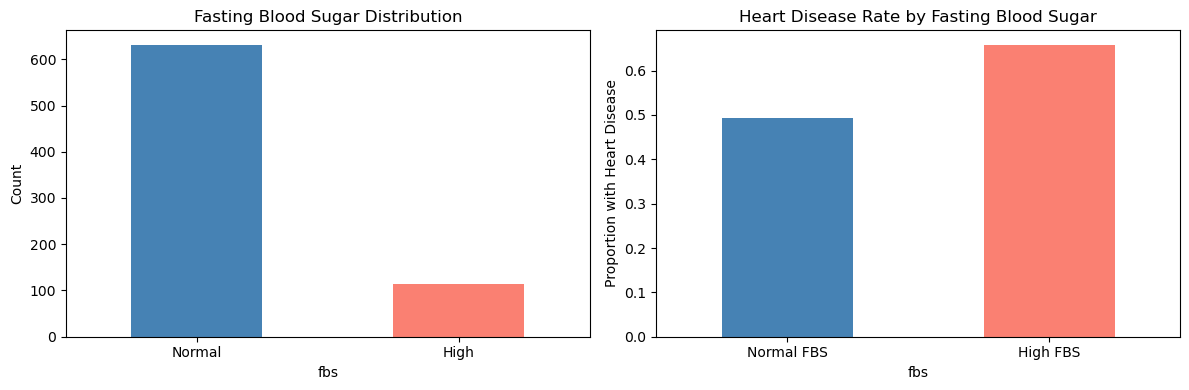

In [15]:
# Disease rate by fbs group
print("Disease rate by fasting blood sugar:")
print(df.groupby('fbs')['target'].mean().rename({0: 'Normal FBS', 1: 'High FBS'}))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Treatment distribution
df['fbs'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'])
axes[0].set_title('Fasting Blood Sugar Distribution')
axes[0].set_xticklabels(['Normal', 'High'], rotation=0)
axes[0].set_ylabel('Count')

# Outcome by treatment
df.groupby('fbs')['target'].mean().plot(kind='bar', ax=axes[1], color=['steelblue', 'salmon'])
axes[1].set_title('Heart Disease Rate by Fasting Blood Sugar')
axes[1].set_xticklabels(['Normal FBS', 'High FBS'], rotation=0)
axes[1].set_ylabel('Proportion with Heart Disease')

plt.tight_layout()
plt.savefig(r"C:\Users\Disha Sharma\Desktop\Causal_AI\CS1_Healthcare\eda_plot.png", dpi=150)
plt.show()

## 2. Causal Graph (DAG)
We define the causal structure using a Directed Acyclic Graph (DAG).
Confounders affect both treatment assignment and the outcome, creating backdoor paths
that must be blocked to isolate the true causal effect.

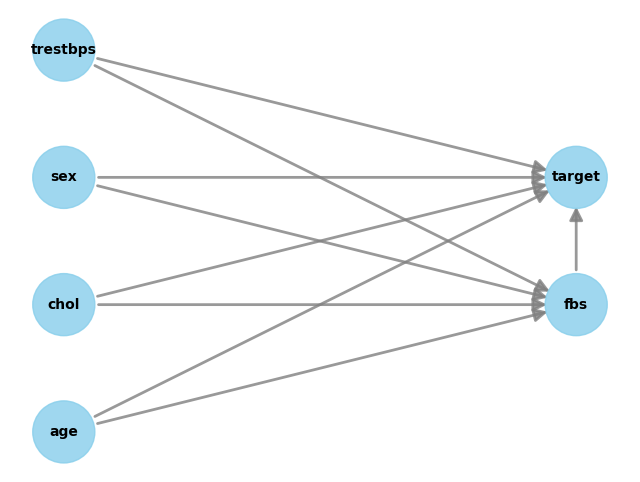

In [17]:
# Define the causal graph using DoWhy
# Confounders (age, sex, chol, trestbps) affect both treatment (fbs) and outcome (target)
model = CausalModel(
    data=df,
    treatment='fbs',
    outcome='target',
    common_causes=['age', 'sex', 'chol', 'trestbps']
)

# Visualize the DAG
model.view_model()

## 3. Causal Identification
DoWhy identifies the backdoor adjustment set -- the variables that need to be controlled
for to satisfy the backdoor criterion and make the causal effect identifiable.

In [19]:
# DoWhy identifies how to estimate the causal effect given the graph
identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
  d                                    
──────(E[target|age,chol,sex,trestbps])
d[fbs]                                 
Estimand assumption 1, Unconfoundedness: If U→{fbs} and U→target then P(target|fbs,age,chol,sex,trestbps,U) = P(target|fbs,age,chol,sex,trestbps)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
  d                                    
──────(E[target|age,chol,sex,trestbps])
d[fbs]                                 
Estimand assumption 1, Unconfoundedness: If U→{fbs} and U→target then P(target|fbs,age,chol,sex,trestbps,U) = P(target|fbs,age,chol,sex,trestbps)



## 4. Causal Effect Estimation
We estimate the Average Treatment Effect (ATE) using linear regression adjustment
on the identified backdoor variables.

In [21]:
# Estimate ATE using linear regression adjustment (backdoor method)
estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression",
    test_significance=True
)

print(estimate)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
  d                                    
──────(E[target|age,chol,sex,trestbps])
d[fbs]                                 
Estimand assumption 1, Unconfoundedness: If U→{fbs} and U→target then P(target|fbs,age,chol,sex,trestbps,U) = P(target|fbs,age,chol,sex,trestbps)

## Realized estimand
b: target~fbs+age+chol+sex+trestbps
Target units: ate

## Estimate
Mean value: 0.04306266165859962
p-value: [0.3693766]



## 5. Refutation Tests
Two robustness checks:
- **Random common cause:** Adds a random confounder -- estimate should remain stable
- **Placebo treatment:** Replaces treatment with noise -- estimate should drop to near zero

In [23]:
# Refute the estimate by adding a random common cause -- if estimate changes drastically, it's unreliable
refutation = model.refute_estimate(
    identified_estimand,
    estimate,
    method_name="random_common_cause"
)
print(refutation)

Refute: Add a random common cause
Estimated effect:0.04306266165859962
New effect:0.0431417690362642
p value:0.9199999999999999



In [25]:
# Replace treatment with a random placebo -- causal effect should drop to near zero
refutation2 = model.refute_estimate(
    identified_estimand,
    estimate,
    method_name="placebo_treatment_refuter",
    placebo_type="permute"
)
print(refutation2)

Refute: Use a Placebo Treatment
Estimated effect:0.04306266165859962
New effect:0.004036780950962264
p value:0.9199999999999999



## 6. Summary
Visual comparison of naive vs causal estimates and refutation results.

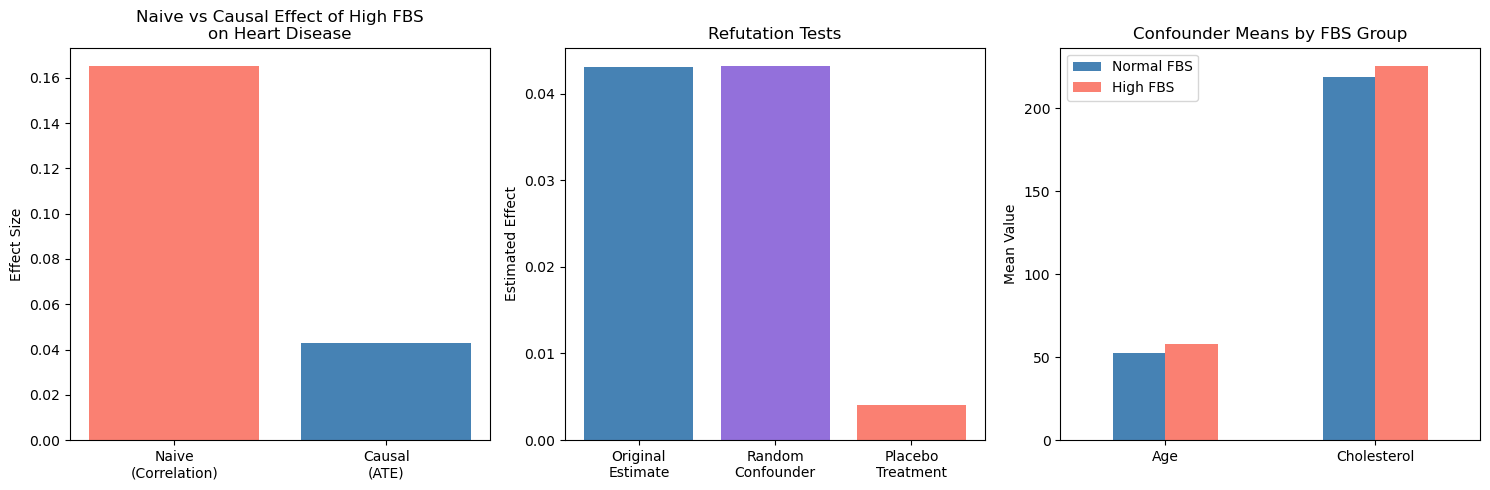

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Naive vs Causal estimate
naive_effect = df.groupby('fbs')['target'].mean()[1] - df.groupby('fbs')['target'].mean()[0]
causal_effect = 0.04306

axes[0].bar(['Naive\n(Correlation)', 'Causal\n(ATE)'], 
            [naive_effect, causal_effect], 
            color=['salmon', 'steelblue'])
axes[0].set_title('Naive vs Causal Effect of High FBS\non Heart Disease')
axes[0].set_ylabel('Effect Size')

# Plot 2: Refutation results
axes[1].bar(['Original\nEstimate', 'Random\nConfounder', 'Placebo\nTreatment'],
            [0.04306, 0.04314, 0.00404],
            color=['steelblue', 'mediumpurple', 'salmon'])
axes[1].set_title('Refutation Tests')
axes[1].set_ylabel('Estimated Effect')

# Plot 3: Confounder distributions by treatment group
df.groupby('fbs')[['age', 'chol']].mean().T.plot(
    kind='bar', ax=axes[2], color=['steelblue', 'salmon']
)
axes[2].set_title('Confounder Means by FBS Group')
axes[2].set_xticklabels(['Age', 'Cholesterol'], rotation=0)
axes[2].legend(['Normal FBS', 'High FBS'])
axes[2].set_ylabel('Mean Value')

plt.tight_layout()
plt.savefig(r"C:\Users\Disha Sharma\Desktop\Causal_AI\CS1_Healthcare\summary_plot.png", dpi=150)
plt.show()